In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/Phanton60_right_37.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/Phanton60_right_45.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/Phanton60_right_25.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/Phanton60_right_40.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/phanton60_left_8_66.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/phanton60_left_8_69.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/Phanton60_right_48.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/phanton60_left_8_78.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/phanton60_left_8_73.png
/kaggle/input/spectrogram-image-classification/dataset_spetr

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

import matplotlib.pyplot as plt # For data viz
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm

print('System Version:', sys.version)
print('PyTorch version', torch.__version__)
print('Torchvision version', torchvision.__version__)
print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)

System Version: 3.12.8 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:48:34) [MSC v.1929 64 bit (AMD64)]
PyTorch version 2.3.1
Torchvision version 0.18.1a0
Numpy version 1.26.4
Pandas version 2.2.2


In [2]:
class SpectrogramImagesDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]
    
    @property
    def classes(self):
        return self.data.classes

In [3]:
dataset = SpectrogramImagesDataset(
    data_dir=r'D:\Dataset_Sationary_Spectrograms\train'
)

In [4]:
len(dataset)

14760

0


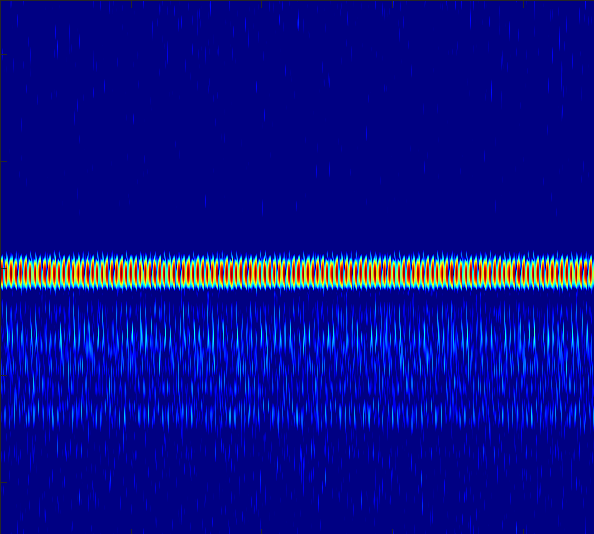

In [5]:
image, label = dataset[125]
print(label)
image

In [6]:
# Get a dictionary associating target values with folder names
data_dir = r'D:\Dataset_Sationary_Spectrograms\train'
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}
print(target_to_class)

{0: 'environment', 1: 'hexacoptor', 2: 'phantom', 3: 'rcplane1', 4: 'rcplane2'}


In [7]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

data_dir = r'D:\Dataset_Sationary_Spectrograms\train'
dataset = SpectrogramImagesDataset(data_dir, transform)

In [8]:
image, label = dataset[100]
image.shape

torch.Size([3, 128, 128])

In [9]:
# iterate over dataset
for image, label in dataset:
    break

In [10]:
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [11]:
for images, labels in dataloader:
    break

In [12]:
images.shape, labels.shape

(torch.Size([8, 3, 128, 128]), torch.Size([8]))

In [13]:
labels

tensor([1, 0, 1, 2, 2, 0, 1, 3])

In [24]:
class SimpleSpectrogramImagesClassifer(nn.Module):
    def __init__(self, num_classes=5):
        super(SimpleSpectrogramImagesClassifer, self).__init__()
        # Where we define all the parts of the model
        self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 1280
        # Make a classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(enet_out_size, num_classes)
        )
    
    def forward(self, x):
        # Connect these parts and return the output
        x = self.features(x)
        output = self.classifier(x)
        return output

In [25]:
model = SimpleSpectrogramImagesClassifer(num_classes=5)
print(str(model)[:500])

SimpleSpectrogramImagesClassifer(
  (base_model): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups


In [26]:
example_out = model(images)
example_out.shape # [batch_size, num_classes]

torch.Size([8, 5])

In [27]:
# Loss function
criterion = nn.CrossEntropyLoss()
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [28]:
criterion(example_out, labels)
print(example_out.shape, labels.shape)

torch.Size([8, 5]) torch.Size([8])


In [29]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_folder = r'D:\Dataset_Sationary_Spectrograms\train'
valid_folder = r'D:\Dataset_Sationary_Spectrograms\valid'
test_folder = r'D:\Dataset_Sationary_Spectrograms\test'

train_dataset = SpectrogramImagesDataset(train_folder, transform=transform)
val_dataset = SpectrogramImagesDataset(valid_folder, transform=transform)
test_dataset = SpectrogramImagesDataset(test_folder, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [31]:
all_labels = []
for _, labels in train_loader:
    all_labels.extend(labels.tolist())
print(f"Unique labels in the dataset: {set(all_labels)}")


Unique labels in the dataset: {0, 1, 2, 3, 4}


In [32]:
# Simple training loop
num_epochs = 5
train_losses, val_losses = [], []

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = SimpleSpectrogramImagesClassifer(num_classes=5)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc='Training loop'):
        # Move inputs and labels to the device
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # Validation phase
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation loop'):
            # Move inputs and labels to the device
            images, labels = images.to(device), labels.to(device)
         
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss}, Validation loss: {val_loss}")

Training loop:   0%|          | 0/1845 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/568 [00:00<?, ?it/s]

Epoch 1/5 - Train loss: 0.27346735906630737, Validation loss: 0.7202580816067329


Training loop:   0%|          | 0/1845 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/568 [00:00<?, ?it/s]

...

Validation loop:   0%|          | 0/568 [00:00<?, ?it/s]

Epoch 4/5 - Train loss: 0.0359966510543555, Validation loss: 0.2449891670738767


Training loop:   0%|          | 0/1845 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/568 [00:00<?, ?it/s]

Epoch 5/5 - Train loss: 0.03425994249590071, Validation loss: 0.3789040656291342


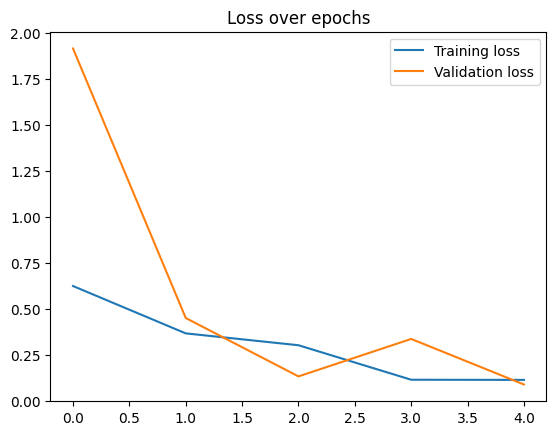

In [24]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

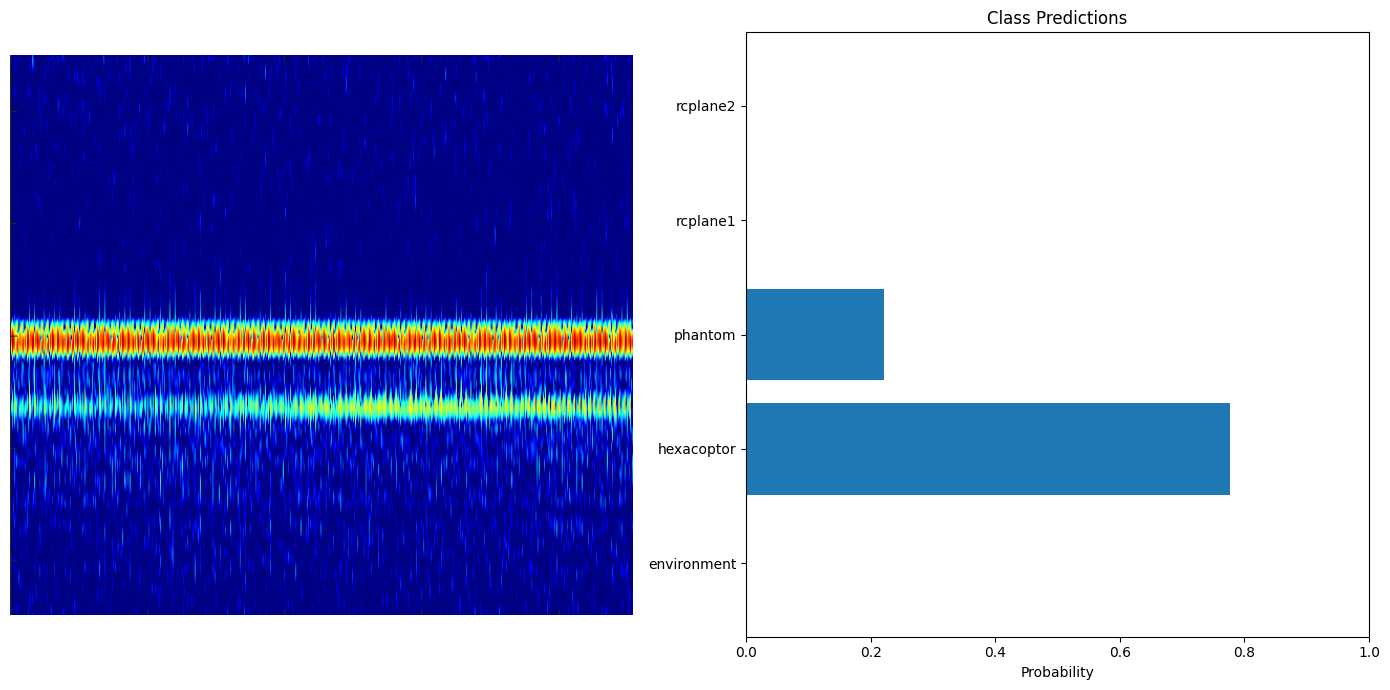

In [41]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess the image
def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    return image, transform(image).unsqueeze(0)

# Predict using the model
def predict(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    return probabilities.cpu().numpy().flatten()

# Visualization
def visualize_predictions(original_image, probabilities, class_names):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 7))
    
    # Display image
    axarr[0].imshow(original_image)
    axarr[0].axis("off")
    
    # Display predictions
    axarr[1].barh(class_names, probabilities)
    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

# Example usage
test_image = r'D:\Dataset_Sationary_Spectrograms\test\phantom\img20.png'
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

original_image, image_tensor = preprocess_image(test_image, transform)
probabilities = predict(model, image_tensor, device)

# Assuming dataset.classes gives the class names
class_names = dataset.classes 
visualize_predictions(original_image, probabilities, class_names)

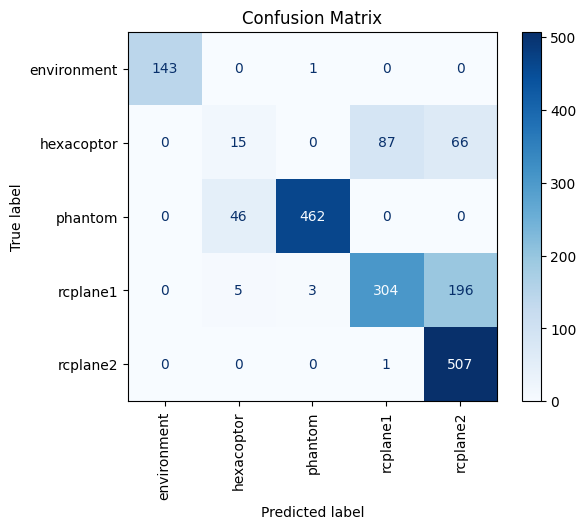

In [42]:
import torch
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Load the test dataset
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

test_dir = r'D:\Dataset_Sationary_Spectrograms\test'
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

# Define the evaluation function
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds)

# Plot the confusion matrix
def plot_confusion_matrix(labels, preds, class_names):
    cm = confusion_matrix(labels, preds, labels=np.arange(len(class_names)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
    plt.title("Confusion Matrix")
    plt.show()

# Assuming `model` and `device` are defined
labels, preds = evaluate_model(model, test_loader, device)
class_names = test_dataset.classes
plot_confusion_matrix(labels, preds, class_names)


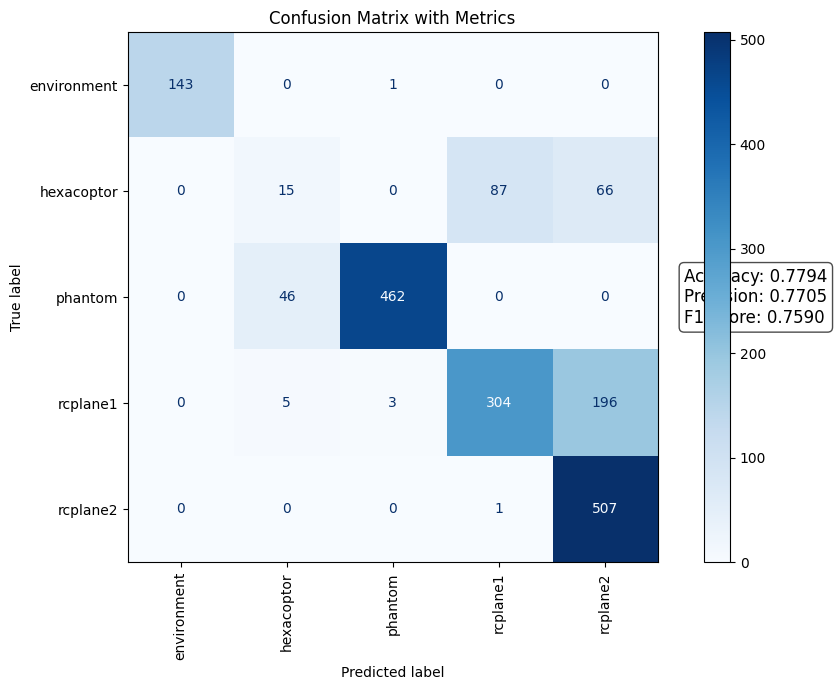

In [43]:
import torch
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Load the test dataset
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

test_dir = r'D:\Dataset_Sationary_Spectrograms\test'
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

# Define the evaluation function
def evaluate_model_metrics(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds)

# Compute and display confusion matrix and metrics
def plot_metrics_with_confusion_matrix(labels, preds, class_names):
    # Compute confusion matrix
    cm = confusion_matrix(labels, preds, labels=np.arange(len(class_names)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    # Compute metrics
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='weighted', zero_division=0)
    f1 = f1_score(labels, preds, average='weighted', zero_division=0)

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(10, 7))
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')

    # Add metrics as text
    metrics_text = (f"Accuracy: {accuracy:.4f}\n"
                    f"Precision: {precision:.4f}\n"
                    f"F1 Score: {f1:.4f}")
    plt.gca().text(1.05, 0.5, metrics_text, transform=plt.gca().transAxes, fontsize=12,
                   verticalalignment='center', bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    plt.title("Confusion Matrix with Metrics")
    plt.tight_layout()
    plt.show()

# Assuming `model` and `device` are defined
labels, preds = evaluate_model_metrics(model, test_loader, device)
class_names = test_dataset.classes

# Plot metrics and confusion matrix
plot_metrics_with_confusion_matrix(labels, preds, class_names)


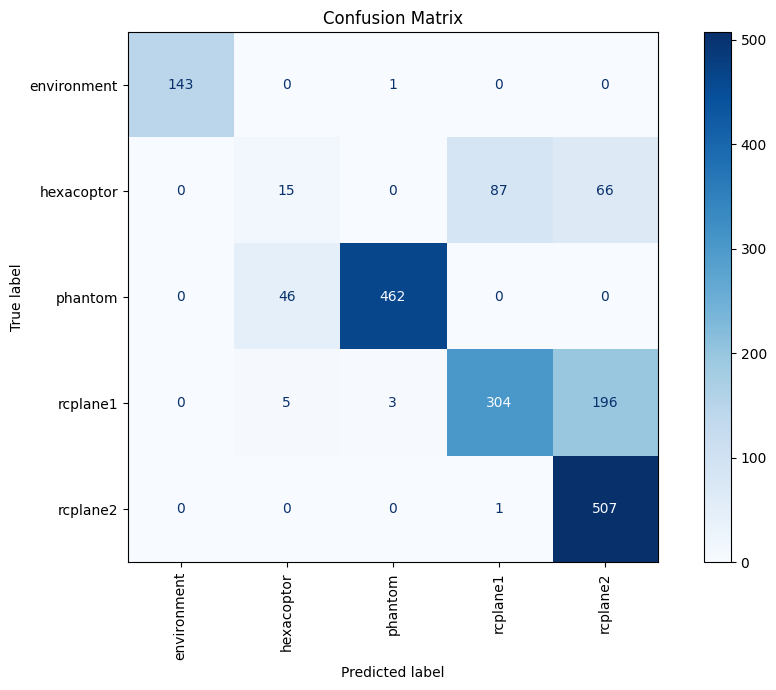


Accuracy: 0.7794
Precision (Weighted): 0.7705
F1 Score (Weighted): 0.7590


In [44]:
import torch
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Load the test dataset
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

test_dir = r'D:\Dataset_Sationary_Spectrograms\test'
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

# Define the evaluation function
def evaluate_model_metrics(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds)

# Compute and display confusion matrix and metrics
def plot_confusion_matrix_with_metrics(labels, preds, class_names):
    # Compute confusion matrix
    cm = confusion_matrix(labels, preds, labels=np.arange(len(class_names)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(10, 7))
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # Compute metrics
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='weighted', zero_division=0)
    f1 = f1_score(labels, preds, average='weighted', zero_division=0)

    # Print metrics below the matrix
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Precision (Weighted): {precision:.4f}")
    print(f"F1 Score (Weighted): {f1:.4f}")

# Assuming `model` and `device` are defined
labels, preds = evaluate_model_metrics(model, test_loader, device)
class_names = test_dataset.classes

# Plot confusion matrix and print metrics
plot_confusion_matrix_with_metrics(labels, preds, class_names)


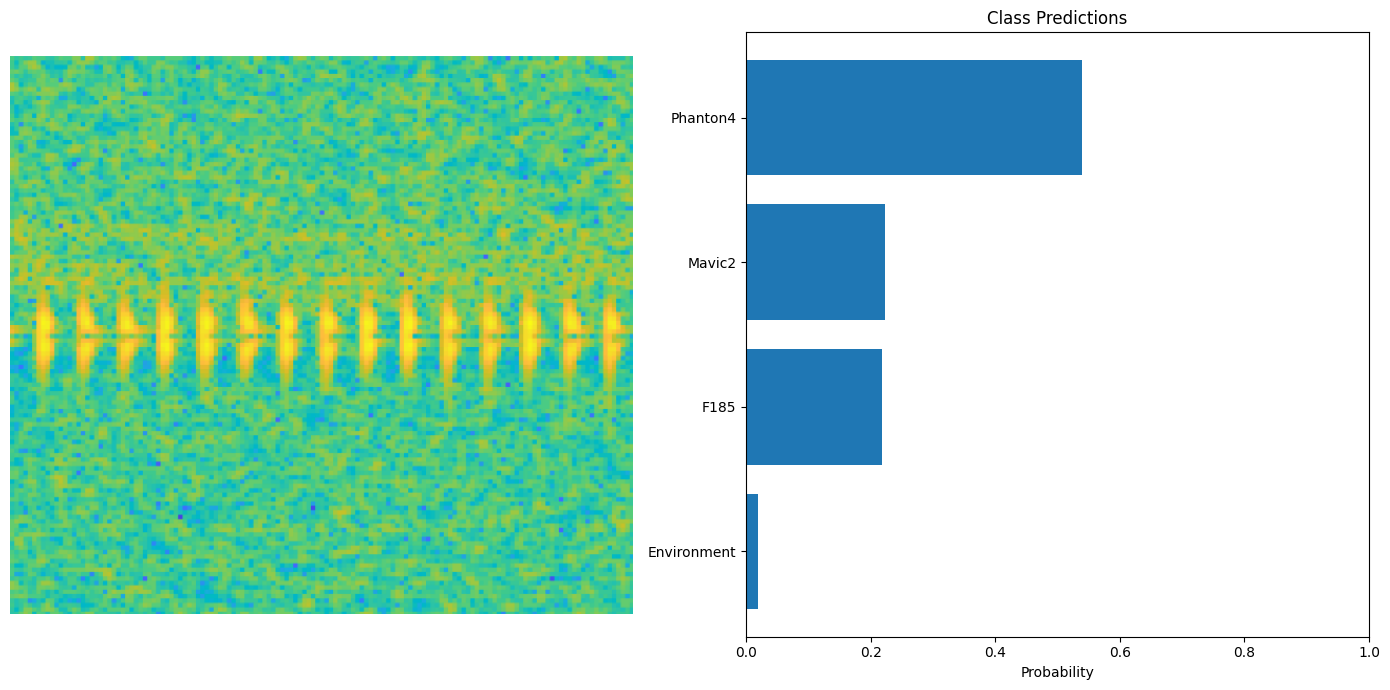

In [27]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess the image
def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    return image, transform(image).unsqueeze(0)

# Predict using the model
def predict(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    return probabilities.cpu().numpy().flatten()

# Visualization
def visualize_predictions(original_image, probabilities, class_names):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 7))
    
    # Display image
    axarr[0].imshow(original_image)
    axarr[0].axis("off")
    
    # Display predictions
    axarr[1].barh(class_names, probabilities)
    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

# Example usage
test_image = "D:/Drone-Swarm-Detection-with-AWR2243/Our data/Radar_Data/dataset_spetrogram/test/Mavic2/Waruna_up_forward_42.png"
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

original_image, image_tensor = preprocess_image(test_image, transform)
probabilities = predict(model, image_tensor, device)

# Assuming dataset.classes gives the class names
class_names = dataset.classes 
visualize_predictions(original_image, probabilities, class_names)